In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from denoise.denoise_methods import noise_reduce_denoise, high_pass_filter
from features.extract_features import get_mel_spectrogram, get_mfcc
from models import LSTMModel, GRUModel, RNNModel, DecisionTreeModel
from utils import min_max_scaler, pad_audio

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DCASE2024_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2024"

DCASE2024_TRAIN_PATH = DCASE2024_ROOT_PATH / "Train"
DCASE2024_DEV_PATH = DCASE2024_ROOT_PATH / "Dev"
DCASE2024_EVAL_PATH = DCASE2024_ROOT_PATH / "Eval"

DCASE2022_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2022"

DCASE2022_TRAIN_PATH = DCASE2022_ROOT_PATH / "Train"
DCASE2022_DEV_PATH = DCASE2022_ROOT_PATH / "Dev"

# ===============================================================
# ===============================================================

SAMPLE_RATE = 24_000

MEL_SPECTROGRAM_PARAMS = {
    "n_fft": 128,
    "sr": SAMPLE_RATE,
    "hop_length": 512,
    "window": "hann",
    "center": True,
    "pad_mode": "constant",
    "power": 2.0,
}

MFCC_PARAMS = {
    "sr": SAMPLE_RATE,
    "n_mfcc": 13,
    "dct_type": 2,
    "norm": "ortho",
    "lifter": 0,
}

In [ ]:
def load_audio(audio):
    signal, sample_rate = librosa.load(audio, sr=SAMPLE_RATE)

    return signal, sample_rate

def get_features(signals):
    X_mel_spectrogram = []
    X_mfcc = []

    for signal in signals:
        mel = get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS)
        mfcc = get_mfcc(mel, MFCC_PARAMS)

        X_mel_spectrogram.append(mel)
        X_mfcc.append(mfcc)

    return X_mel_spectrogram, X_mfcc

# Leitura dos áudios


In [4]:
def read_dcase_dev_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        for section in ["train", "test"]:
            data_dir = machine_dir / section
            if not data_dir.exists():
                continue

            for audio_file in tqdm(data_dir.iterdir(), desc=f"Lendo {section}"):
                if audio_file.suffix != ".wav":
                    continue

                try:
                    if "anomaly" in audio_file.name:
                        label = 1
                    else:
                        label = 0

                    signal, _ = load_audio(audio_file)

                    X.append(signal)
                    machine_type.append(machine_dir.name)
                    y.append(label)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_train_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "train"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo train"):
            if audio_file.suffix != ".wav":
                continue
            try:
                label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_eval_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "test"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo eval"):
            if audio_file.suffix != ".wav":
                continue
            try:
                if "anomaly" in audio_file.name:
                    label = 1
                else:
                    label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y

In [ ]:
# Conjuntos que o artigo usa

# 25.199 áudios (treino e teste) - DCASE 2022/MIMII DG
#X_dcase22, mtypes_dcase22, y_dcase22 = read_dcase_dev_set(DCASE2022_DEV_PATH)

# # 9.000 áudios (treino) - DCASE 2024
# X_dcase24_train, mtypes_dcase24_train, y_dcase24_train = read_dcase_train_set(DCASE2024_TRAIN_PATH)

# # 1.800 áudios (teste) - DCASE 2024
# X_dcase24_test, mtypes_dcase24_test, y_dcase24_test = read_dcase_eval_set(DCASE2024_EVAL_PATH)

# # União do conjunto DCASE 2024
# X_dcase24 = X_dcase24_test + X_dcase24_train
# mtypes_dcase24 = mtypes_dcase24_test + mtypes_dcase24_train
# y_dcase24 = y_dcase24_test + y_dcase24_train

In [8]:
data, machine_type, y = read_dcase_eval_set(DCASE2024_EVAL_PATH)

print("Leitura Concluída!")
print(f"Total de amostras: {len(y)}")
print(f"Máquinas: {np.unique(machine_type)}")
print(f"Classes encontradas em y: {np.unique(y)}")

Lendo eval: 0it [00:00, ?it/s]c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Lendo eval: 200it [00:01, 140.62it/s]
Lendo eval: 200it [00:00, 498.74it/s]
Lendo eval: 200it [00:00, 749.79it/s]
Lendo eval: 200it [00:00, 724.79it/s]
Lendo eval: 200it [00:00, 635.10it/s]
Lendo eval: 200it [00:00, 657.10it/s]
Lendo eval: 200it [00:00, 499.12it/s]
Lendo eval: 200it [00:00, 805.94it/s]
Lendo eval: 200it [00:00, 492.22it/s]

Leitura Concluída!
Total de amostras: 1800
Máquinas: ['3DPrinter' 'AirCompressor' 'BrushlessMotor' 'HairDryer' 'HoveringDrone'
 'RoboticArm' 'Scanner' 'ToothBrush' 'ToyCircuit']
Classes encontradas em y: [0 1]


In [15]:
denoised_data = [denoise(signal, SAMPLE_RATE) for signal in data]
pad_data = [pad_audio(signal) for signal in denoised_data]

X_mel_spectrogram = [get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS) for signal in pad_data]
X_norm_mel_spectrogram = [min_max_scaler(mel) for mel in X_mel_spectrogram]

X_mfcc = [get_mfcc(mel, MFCC_PARAMS) for mel in X_mel_spectrogram]
X_norm_mfcc = [min_max_scaler(mfcc) for mfcc in X_mfcc]

sets1 = train_test_split(X_norm_mel_spectrogram, y, test_size=0.2, random_state=42, shuffle=True)
sets2 = train_test_split(X_norm_mfcc, y, test_size=0.2, random_state=42, shuffle=True)

X_mel_spectrogram_train,  X_mel_spectrogram_test, y_train, y_test = sets1
X_mfcc_train, X_mfcc_test, _, _ = sets2

c:\Users\josel\OneDrive\Desktop\NCIA\.venv\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [16]:
if len(X_mel_spectrogram) > 0:
    print(f"Formato de um Mel-Spectrograma: {X_mel_spectrogram[0].shape}")

Formato de um Mel-Spectrograma: (128, 469)


1


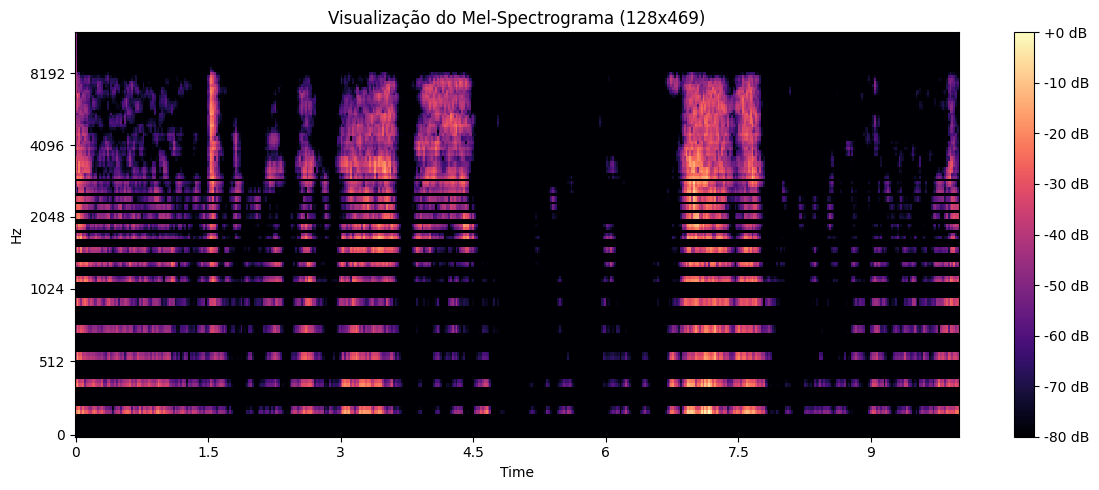

In [17]:
i = 4

imagem = X_mel_spectrogram[i]
print(y[i])

plt.figure(figsize=(12, 5))
librosa.display.specshow(imagem, sr=24000, hop_length=512, x_axis="time", y_axis="mel")

plt.colorbar(format="%+2.0f dB")
plt.title("Visualização do Mel-Spectrograma (128x469)")
plt.tight_layout()
plt.show()

In [62]:
classes, contagem = np.unique(y, return_counts=True)

print(f"Normais (0): {contagem[0]}")
print(f"Anomalias (1): {contagem[1]}")

Normais (0): 900
Anomalias (1): 900


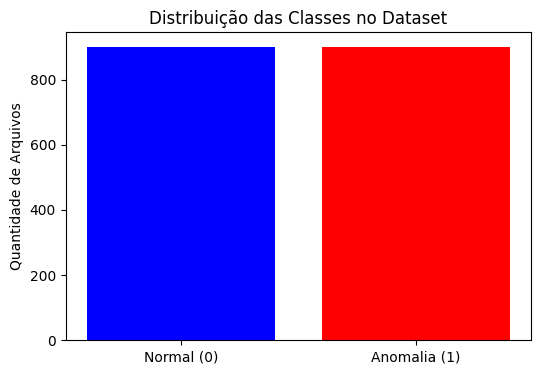

In [63]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Anomalia (1)"], counts, color=["blue", "red"])
plt.title("Distribuição das Classes no Dataset")
plt.ylabel("Quantidade de Arquivos")
plt.show()

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gru_model = GRUModel(input_size=13, num_classes=2).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
X_train_flat = np.array([x.flatten() for x in X_mfcc_train])
y_train_arr = np.array(y_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in skf.split(X_train_flat, y_train_arr):

    # Separação dos dados de treino e validação para o fold atual
    X_train_fold, X_val_fold = X_train_flat[train_idx], X_train_flat[val_idx]
    y_train_fold, y_val_fold = y_train_arr[train_idx], y_train_arr[val_idx]

    # Instancia o modelo com os parâmetros e treina
    clf = DecisionTreeModel(**params)
    clf.fit(X_train_fold, y_train_fold)

    # Faz as previsões no conjunto de validação do fold
    y_pred = clf.predict(X_val_fold)

    # Calcula e salva a acurácia
    fold_acc = accuracy_score(y_val_fold, y_pred)
    scores.append(fold_acc)

print(f"Acurácias de cada fold: {[f'{s:.4f}' for s in scores]}")
print(f"Acurácia Média (Validação Cruzada): {np.mean(scores):.4f} +/- {np.std(scores):.4f}")

NameError: name 'X_mfcc_train' is not defined